## Manually Run ArgosQC for WildlifeComputers Tags - ArgosQC.wc_qc

1. Install required R package(s).
2. Run wc_qc for specified configuration file.

### Install ArgosQC package 

TODO: Pin to a stable verion. Only run as instructed by OTN data team.

~~run this everytime to upgrade to the latest

In [ ]:
options(install.packages.check.source = "no")

# Unload package prior to reinstall/update
unloadNamespace("ArgosQC")
remotes::install_github("ianjonsen/ArgosQC", force = TRUE, INSTALL_opts = "--no-multiarch", dependency=NA)

# Load package and check version
library(ArgosQC)
packageDescription("ArgosQC", fields = "Version")

### (Optional) If failed to install ArgosQC, uncomment `install.packages` run row(s) to install missing dependent package(s).

In [ ]:
# install.packages(c("terra", "units", "dplyr"))
# install.packages(c('sfnetworks', 'igraph', 'lwgeom', 'nabor'))

### (Optional)  If failed to install ArgosQC,  uncomment `remotes::install_github` row(s) to install missing dependent package(s).

In [ ]:
## The main SSM package
# remotes::install_github("ianjonsen/aniMotum", force = TRUE, INSTALL_opts = "--no-multiarch")
library(aniMotum)

## Package to reroute locations off land
# remotes::install_github("jmlondon/pathroutr", force = TRUE)
library(pathroutr)

## (Optional) Package to change map scale/resolution. Without this package map_scale will be set to 50 (medium resolution).

# remotes::install_github("ropensci/rnaturalearthhires")
library(rnaturalearthhires)

### Run ArgosQC.wc_qc for specified configurtion file

#### 1. Syntax and mandatory parameters:

```
wc_qc(
    wd = "<working_dir>",
    config = "<config_wc.json>"
)
```

#### 2. Other wc_qc parameters:  see project vignettes https://github.com/ianjonsen/ArgosQC/blob/main/vignettes/WC_config_file.Rmd


#### 3. Model tunning: run model multiple times with different SSM model parameters. 

📌 `time.step` and `pred.int`: can be decimal (unit in hours) usually between 3 and 12.

- "time.step": 12
- "pred.int": 12 - should be greater than and multiple of `time.step`

#### 4. Expected output

4.1 Fit Model - the first pass

```
Downloading tag data from Wildlife Computers Data Portal...

Reading tag data files...

wc_pull_data() removed from the QC workflow 2 tag dataset(s) with no Locations data: .ipynbwc_pull_data() removed from the QC workflow 2 tag dataset(s) with no Locations data: 5be7810fefec720dc8d00907

Building deployment metadata from WC Portal...

Preparing location data for QC...

Fitting QC SSM - first pass...
```

💡 `removed from the QC workflow 2 tag dataset(s) with no Locations data`: leave as-is as new tags may not have enough location data. 


4.2 Fit Model - the second pass

```
Fitting QC SSM - second pass & rerouting locations off land...

QC'd locations estimated & rerouted...

Appending QC'd locations to tag data files...

Generating QC diagnostic plots...
```


4.3 Writing QCed results and diagnose

```
using map scale: 10
Writing QC'd data files to .csv...

QC workflow completed
```


In [ ]:
library(ArgosQC)
packageDescription("ArgosQC", fields = "Version")
library(pathroutr)
wc_qc(
    wd = ".",
    config = "input/irap/config_damianlidgard_grey_seal_wc.json"
)


### Interpret output 

See Node Manager Training `Near Real Time (NRT) Animal Movement Location Data Quality Control (QC) Process` https://github.com/ocean-tracking-network/node-manager-training/blob/nrt-ArgosQC/_episodes/30_near_real_time_qc_process.md

1. SSM output: `qc/<program>/<project_name>/ssmoutputs_<common_name>_nrt.csv`

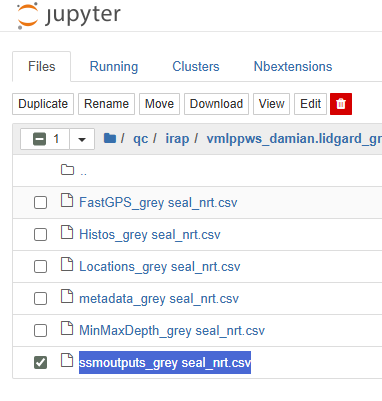


2. Diagnose files: `qc/diag/<program>/[collectioncode]_<collaborator>_common_ame>`

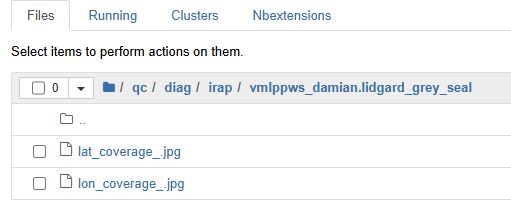

3. Maps: `qc/maps/<program>/[collectioncode]_<collaborator>_<common_ame>` - everytime wc_qc generates a new map without overwriting the previous maps.

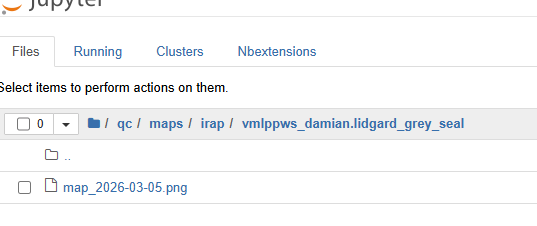